In [87]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from joblib import dump, load
import os
from datetime import datetime
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
warnings.filterwarnings('ignore')
import joblib

## Reading the data

In [88]:
claims = pd.read_csv("FNOL_Data/claims_table.csv")
policy = pd.read_csv("FNOL_Data/policyholder_table.csv")

In [89]:
claims.head()

,Claim_ID,Policy_ID,Customer_ID,Accident_Date,FNOL_Date,Claim_Type,Estimated_Claim_Amount,Ultimate_Claim_Amount,Settlement_Date,Traffic_Condition,Weather_Condition
0,CLM_000001,POL_000001,CUST_77820,2020-03-02,2020-03-06,fire,8761.43,11509.99,2020-06-26,Low,Rainy
1,CLM_000002,POL_000002,CUST_88498,2023-01-09,2023-01-10,fire,12896.76,15470.00,2023-03-21,Low,Rainy
2,CLM_000003,POL_000003,CUST_60735,2022-12-25,2022-12-26,collision,12698.97,13500.00,2023-02-01,Low,Rainy
3,CLM_000004,POL_000003,CUST_60735,2021-11-24,2021-11-29,vandalism,2738.35,2714.92,2021-12-13,Moderate,Stormy
4,CLM_000005,POL_000003,CUST_60735,2022-10-01,2022-10-08,collision,16262.58,NaN,2022-12-06,Moderate,Rainy


In [90]:
policy.head()

,Policy_ID,Customer_ID,Date_of_Birth,Full_License_Issue_Date,Vehicle_Type,Vehicle_Year
0,POL_000001,CUST_77820,1983-04-20,2003-08-23,Sedan,2008
1,POL_000002,CUST_88498,1986-03-10,2007-07-26,Hatchback,2012
2,POL_000003,CUST_60735,1971-03-02,1989-07-05,Hatchback,2021
3,POL_000004,CUST_54707,1946-09-19,1968-01-12,Truck,2022
4,POL_000005,CUST_26658,1957-07-26,1977-08-07,SUV,2006


### 1. Data Preparation

Merge datasets: Join claims with policies/customers on Policy_ID to get a unified dataset with customer, vehicle, and claim information.

Data cleaning:

* Convert dates to datetime objects
* Handle missing values (.fillna() or .dropna())

#### Feature engineering:

* Reporting_Delay = FNOL_Date - Accident_Date

* Settlement_Duration = Settlement_Date - FNOL_Date

* driver_age = Accident_Date – Date_of_Birth

* license_age = Accident_Date – Full_License_Issue_Date

* vehicle_age = Accident_Date – Vehicle_Year

* fnol_delay = FNOL_Date – Accident_Date

### Merging the Data

In [91]:
claims.shape

(146987, 11)

In [92]:
policy.shape

(120000, 6)

In [93]:
claims_data = pd.merge(claims, policy, on=['Policy_ID', 'Customer_ID'])
claims_data.head() 

,Claim_ID,Policy_ID,Customer_ID,Accident_Date,FNOL_Date,Claim_Type,Estimated_Claim_Amount,Ultimate_Claim_Amount,Settlement_Date,Traffic_Condition,Weather_Condition,Date_of_Birth,Full_License_Issue_Date,Vehicle_Type,Vehicle_Year
0,CLM_000001,POL_000001,CUST_77820,2020-03-02,2020-03-06,fire,8761.43,11509.99,2020-06-26,Low,Rainy,1983-04-20,2003-08-23,Sedan,2008
1,CLM_000002,POL_000002,CUST_88498,2023-01-09,2023-01-10,fire,12896.76,15470.00,2023-03-21,Low,Rainy,1986-03-10,2007-07-26,Hatchback,2012
2,CLM_000003,POL_000003,CUST_60735,2022-12-25,2022-12-26,collision,12698.97,13500.00,2023-02-01,Low,Rainy,1971-03-02,1989-07-05,Hatchback,2021
3,CLM_000004,POL_000003,CUST_60735,2021-11-24,2021-11-29,vandalism,2738.35,2714.92,2021-12-13,Moderate,Stormy,1971-03-02,1989-07-05,Hatchback,2021
4,CLM_000005,POL_000003,CUST_60735,2022-10-01,2022-10-08,collision,16262.58,NaN,2022-12-06,Moderate,Rainy,1971-03-02,1989-07-05,Hatchback,2021


## Data Cleaning

### Checking the dataset information

In [94]:
claims_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146987 entries, 0 to 146986
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Claim_ID                 146987 non-null  object 
 1   Policy_ID                146987 non-null  object 
 2   Customer_ID              146987 non-null  object 
 3   Accident_Date            146987 non-null  object 
 4   FNOL_Date                146987 non-null  object 
 5   Claim_Type               146987 non-null  object 
 6   Estimated_Claim_Amount   143989 non-null  float64
 7   Ultimate_Claim_Amount    144065 non-null  float64
 8   Settlement_Date          146987 non-null  object 
 9   Traffic_Condition        144027 non-null  object 
 10  Weather_Condition        143950 non-null  object 
 11  Date_of_Birth            146987 non-null  object 
 12  Full_License_Issue_Date  146987 non-null  object 
 13  Vehicle_Type             146987 non-null  object 
 14  Vehi

### Checking for missing Values

In [95]:
claims_data.isna().sum()

Claim_ID                      0
Policy_ID                     0
Customer_ID                   0
Accident_Date                 0
FNOL_Date                     0
Claim_Type                    0
Estimated_Claim_Amount     2998
Ultimate_Claim_Amount      2922
Settlement_Date               0
Traffic_Condition          2960
Weather_Condition          3037
Date_of_Birth                 0
Full_License_Issue_Date       0
Vehicle_Type                  0
Vehicle_Year                  0
dtype: int64

### Filling or dropping Missing Values

In [96]:

missing_cols = claims_data.columns[claims_data.isna().any()]

for col in missing_cols:
    print(f"{col}: {claims_data[col].dtype}")


Estimated_Claim_Amount: float64
Ultimate_Claim_Amount: float64
Traffic_Condition: object
Weather_Condition: object


### Fix date columns, convert to datetime, and impute all missing values

In [97]:
date_cols = ['Accident_Date', 'FNOL_Date', 'Settlement_Date', 'Full_License_Issue_Date', 'Date_of_Birth']

# Convert to datetime
claims_data[date_cols] = claims_data[date_cols].apply(pd.to_datetime, errors='coerce')

# Impute numeric columns (median)
for col in ['Estimated_Claim_Amount', 'Ultimate_Claim_Amount']:
    claims_data[col] = claims_data[col].fillna(claims_data[col].median())

# Impute categorical columns (mode)
for col in ['Traffic_Condition', 'Weather_Condition']:
    claims_data[col] = claims_data[col].fillna(claims_data[col].mode()[0])

# Final check
print(claims_data.isna().sum())

Claim_ID                   0
Policy_ID                  0
Customer_ID                0
Accident_Date              0
FNOL_Date                  0
Claim_Type                 0
Estimated_Claim_Amount     0
Ultimate_Claim_Amount      0
Settlement_Date            0
Traffic_Condition          0
Weather_Condition          0
Date_of_Birth              0
Full_License_Issue_Date    0
Vehicle_Type               0
Vehicle_Year               0
dtype: int64


#### Checking data information after the date was fixed.

In [98]:
claims_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146987 entries, 0 to 146986
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Claim_ID                 146987 non-null  object        
 1   Policy_ID                146987 non-null  object        
 2   Customer_ID              146987 non-null  object        
 3   Accident_Date            146987 non-null  datetime64[ns]
 4   FNOL_Date                146987 non-null  datetime64[ns]
 5   Claim_Type               146987 non-null  object        
 6   Estimated_Claim_Amount   146987 non-null  float64       
 7   Ultimate_Claim_Amount    146987 non-null  float64       
 8   Settlement_Date          146987 non-null  datetime64[ns]
 9   Traffic_Condition        146987 non-null  object        
 10  Weather_Condition        146987 non-null  object        
 11  Date_of_Birth            146987 non-null  datetime64[ns]
 12  Full_License_Iss

### Check and drop duplicated values

In [99]:
claims_data.duplicated().sum()

0

#### Feature engineering:

* driver_age = Accident_Date – Date_of_Birth

* license_age = Accident_Date – Full_License_Issue_Date

* fnol_delay = FNOL_Date – Accident_Date

In [100]:
# Driving Age feature derived
claims_data["Driver_age"] = (claims_data["Accident_Date"] - claims_data["Date_of_Birth"]).dt.days // 365
# License Age feature derived
claims_data["License_age"] = (claims_data["Accident_Date"] - claims_data["Full_License_Issue_Date"]).dt.days // 365
# Fnol delay feature derived
claims_data["Fnol_delay"] = (claims_data["FNOL_Date"] - claims_data["Accident_Date"]).dt.days
# Settlement days 
claims_data['Settlement_Days'] = (claims_data['Settlement_Date'] - claims_data['FNOL_Date']).dt.days

In [101]:
claims_data.head()

,Claim_ID,Policy_ID,Customer_ID,Accident_Date,FNOL_Date,Claim_Type,Estimated_Claim_Amount,Ultimate_Claim_Amount,Settlement_Date,Traffic_Condition,Weather_Condition,Date_of_Birth,Full_License_Issue_Date,Vehicle_Type,Vehicle_Year,Driver_age,License_age,Fnol_delay,Settlement_Days
0,CLM_000001,POL_000001,CUST_77820,2020-03-02,2020-03-06,fire,8761.43,11509.99,2020-06-26,Low,Rainy,1983-04-20,2003-08-23,Sedan,2008,36,16,4,112
1,CLM_000002,POL_000002,CUST_88498,2023-01-09,2023-01-10,fire,12896.76,15470.00,2023-03-21,Low,Rainy,1986-03-10,2007-07-26,Hatchback,2012,36,15,1,70
2,CLM_000003,POL_000003,CUST_60735,2022-12-25,2022-12-26,collision,12698.97,13500.00,2023-02-01,Low,Rainy,1971-03-02,1989-07-05,Hatchback,2021,51,33,1,37
3,CLM_000004,POL_000003,CUST_60735,2021-11-24,2021-11-29,vandalism,2738.35,2714.92,2021-12-13,Moderate,Stormy,1971-03-02,1989-07-05,Hatchback,2021,50,32,5,14
4,CLM_000005,POL_000003,CUST_60735,2022-10-01,2022-10-08,collision,16262.58,10965.84,2022-12-06,Moderate,Rainy,1971-03-02,1989-07-05,Hatchback,2021,51,33,7,59


# Exploratory Data Analysis

1. Basic dataset Overview
    a. the highest estimated claim amount and the lowest estimated claim amount
    
    b. the highest ultimate claim amount and the lowest ultimate claim amount
    
    c. age range from the youngest to the oldest customers
    
    d. the claim type with the highest to the lowest claim amount
    
    e. traffic condition that appears in the claims the most
    
    f. weather condition that appears in the claims the most
    
    g. weather and traffic condition that tends to have impact in terms of the claim amount monetary, that is which type of weather conditions cost the company more.
 

In [ ]:
# claims_data.to_csv("FNOL_Data/Full_claims_data.csv", index=False)

In [102]:
print(" The dataset Overview")
print(" 1. The highest claim amount and the lowest claim amount")
print(f" the lowest claim amount is : {claims_data['Ultimate_Claim_Amount'].min()}, and the highest claim amount is {claims_data['Ultimate_Claim_Amount'].max()}")
print("="*100)
print(" 2. The age range, from the youngest to the lowest customers")
print(f" the youngest customer age is: {claims_data['Driver_age'].min()}, and the oldest customer age is {claims_data['Driver_age'].max()}")
print("="*100)
print(" 3. The claim type with the highest claim amount and the claim type with the lowest claim amount")
claim_type_per_amount = claims_data.groupby("Claim_Type").agg({
    'Estimated_Claim_Amount': 'sum',
    'Ultimate_Claim_Amount': 'sum',
}).reset_index()
print(claim_type_per_amount)
print(f" the claim type with the lowest amount cost is {claim_type_per_amount.loc[claim_type_per_amount['Estimated_Claim_Amount'].idxmin(), 'Claim_Type']}, with total claim amount of {claim_type_per_amount['Estimated_Claim_Amount'].min():,}")
print(f" the claim type with the highest amount cost is {claim_type_per_amount.loc[claim_type_per_amount['Estimated_Claim_Amount'].idxmax(), 'Claim_Type']}, with total claim amount of {claim_type_per_amount['Estimated_Claim_Amount'].max():,}")
print("="*100)
print(" 4. traffic condition that appears most in the claims")
print(f"the following traffic condition tends to appear the most: {claims_data['Traffic_Condition'].value_counts()}")
print("="*100)
print(" 5. Weather condition that appear in the claims the most")
print(f" the following are the weather condition ranges: {claims_data['Weather_Condition'].value_counts()}")
print("="*100)
print("5. weather condition and their impact in claims amount.")
weather_claim_impact = claims_data.groupby("Weather_Condition").agg({
   'Estimated_Claim_Amount': 'sum',
   'Ultimate_Claim_Amount': 'sum',  
}).reset_index()
weather_claim_impact = weather_claim_impact.sort_values('Ultimate_Claim_Amount', ascending= False)
weather_claim_impact.head()

 The dataset Overview
 1. The highest claim amount and the lowest claim amount
 the lowest claim amount is : 450.0, and the highest claim amount is 234000.0
 2. The age range, from the youngest to the lowest customers
 the youngest customer age is: 18, and the oldest customer age is 84
 3. The claim type with the highest claim amount and the claim type with the lowest claim amount
         Claim_Type  Estimated_Claim_Amount  Ultimate_Claim_Amount
0  animal_collision            4.199488e+07           4.197195e+07
1     bodily_injury            6.582306e+08           6.209487e+08
2         collision            7.526246e+08           7.520664e+08
3              fire            5.532218e+08           5.447757e+08
4             glass            2.294494e+07           2.296694e+07
5             theft            5.194864e+08           5.183247e+08
6         vandalism            5.907897e+07           5.945203e+07
 the claim type with the lowest amount cost is glass, with total claim amount of

,Weather_Condition,Estimated_Claim_Amount,Ultimate_Claim_Amount
2,Rainy,1.080873e+09,1.059460e+09
1,Foggy,5.133216e+08,5.030657e+08
3,Snowy,5.053553e+08,4.972387e+08
4,Stormy,2.553265e+08,2.522643e+08
0,Clear,2.527053e+08,2.484780e+08


### Univariate Exploratory Data Analysis

##### 2. Checking the distributions of `Estimated_Claim_Amount`, `Ultimate_Claim_Amount`, `Driver_age`, `License_age`, `Fnol_delay`

Text(0, 0.5, 'Frequency')

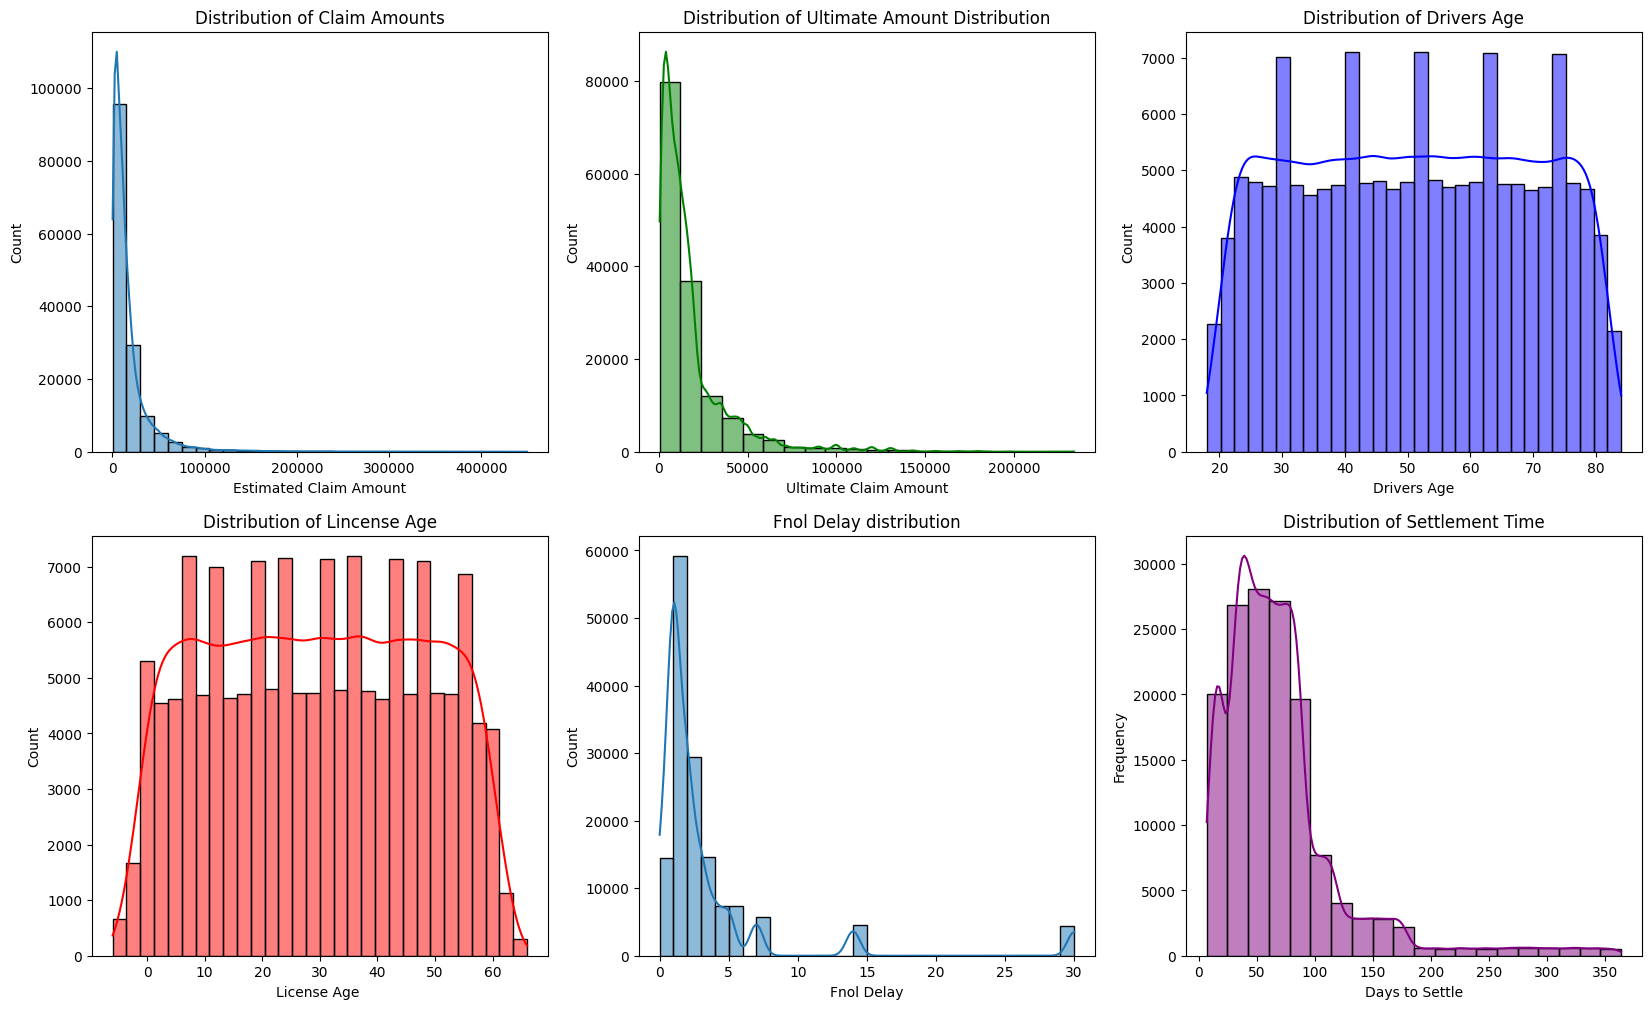

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize = (20, 12))

# Claim Amount Distribution
plt.subplot(2, 3, 1)
sns.histplot(claims_data['Estimated_Claim_Amount'], bins = 30, kde=True)
plt.title("Distribution of Claim Amounts")
plt.xlabel('Estimated Claim Amount')


# Ultimate Amount Distribution
plt.subplot(2, 3, 2)
sns.histplot(claims_data["Ultimate_Claim_Amount"], bins = 20, kde=True, color="green")
plt.title("Distribution of Ultimate Amount Distribution")
plt.xlabel("Ultimate Claim Amount")

# Drivers Age
plt.subplot(2, 3, 3)
sns.histplot(claims_data["Driver_age"], bins = 30, kde= True, color="Blue")
plt.title("Distribution of Drivers Age")
plt.xlabel("Drivers Age")

# License Age
plt.subplot(2, 3, 4)
sns.histplot(claims_data["License_age"], bins = 30, kde = True, color="Red")
plt.title("Distribution of Lincense Age")
plt.xlabel("License Age ")

# Fnol Delay distribution
plt.subplot(2, 3, 5)
sns.histplot(claims_data["Fnol_delay"], bins = 30, kde = True)
plt.title("Fnol Delay distribution")
plt.xlabel("Fnol Delay")

# Distribution of settlement days
plt.subplot(2, 3, 6)
sns.histplot(claims_data['Settlement_Days'], bins=20, kde=True, color='purple')
plt.title('Distribution of Settlement Time')
plt.xlabel('Days to Settle')
plt.ylabel('Frequency')

#### Categorical Analysis - Visualizing weather conditions, traffic condition, claim types and Vehicle Type

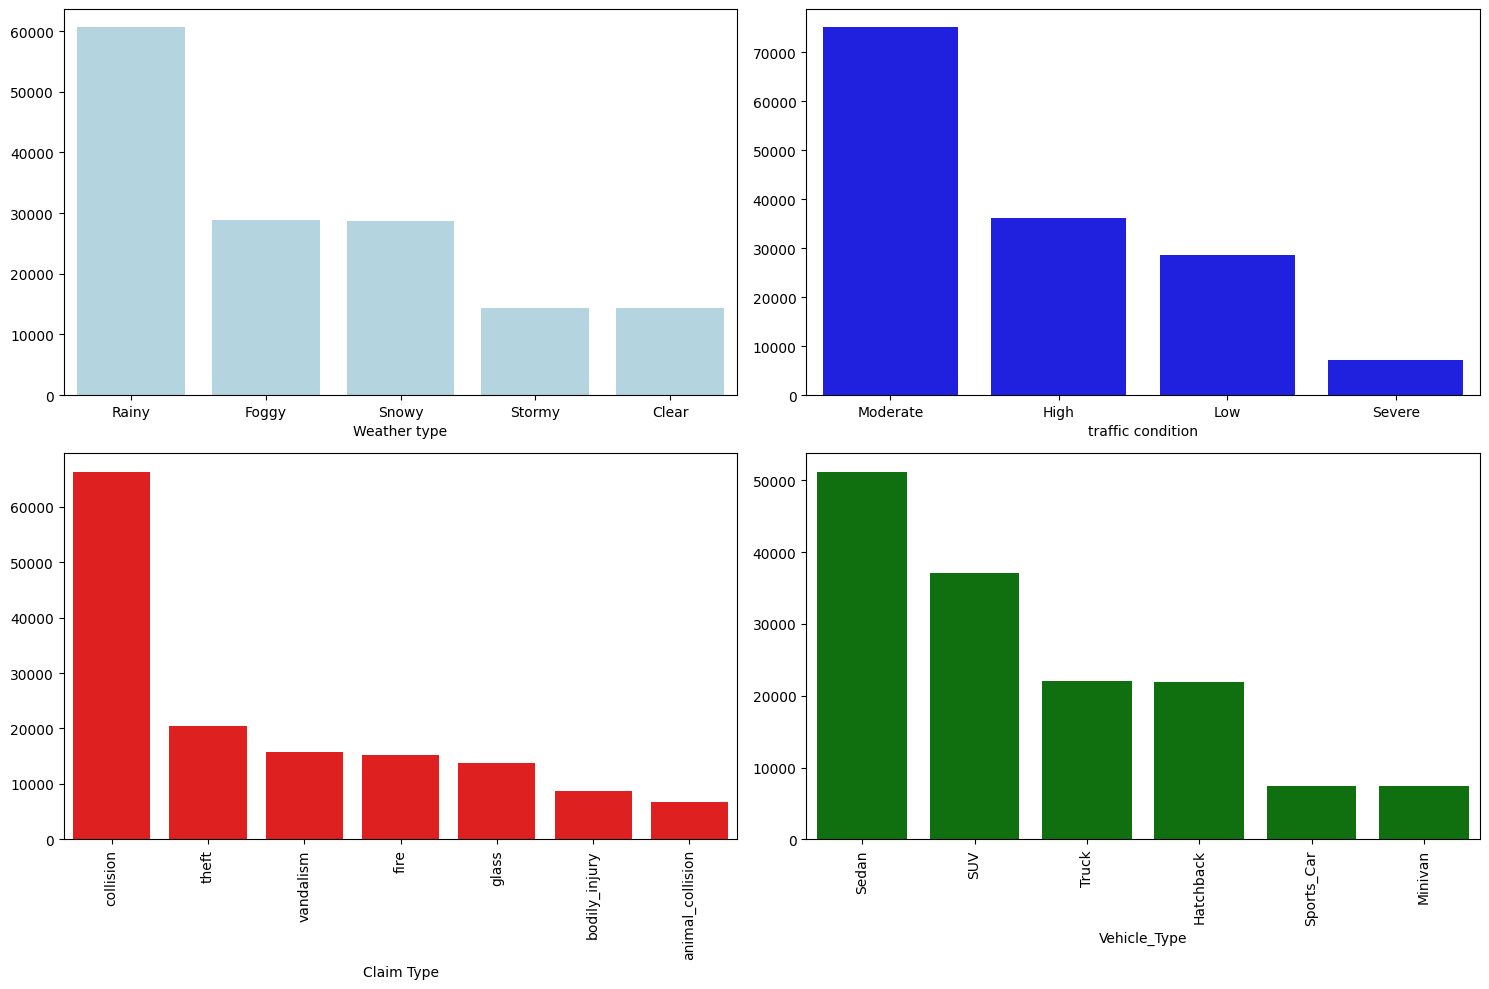

In [34]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
weather = claims_data["Weather_Condition"].value_counts()
sns.barplot(x = weather.index, y = weather.values, color="lightblue")
plt.xlabel("Weather type")

plt.subplot(2, 2, 2)
traffic_condition = claims_data["Traffic_Condition"].value_counts()
sns.barplot(x = traffic_condition.index, y = traffic_condition.values, color = "Blue")
plt.xlabel("traffic condition")

plt.subplot(2, 2, 3)
claim_type = claims_data["Claim_Type"].value_counts()
sns.barplot(x = claim_type.index, y = claim_type.values, color = "Red")
plt.xlabel("Claim Type")
plt.xticks(rotation="vertical")


plt.subplot(2, 2, 4)
Vehicle_Type = claims_data["Vehicle_Type"].value_counts()
sns.barplot(x = Vehicle_Type.index, y=Vehicle_Type.values, color = "Green")
plt.xlabel("Vehicle_Type")
plt.xticks(rotation="vertical")

plt.tight_layout()
plt.show()

## Seasonal claims Trends across the years

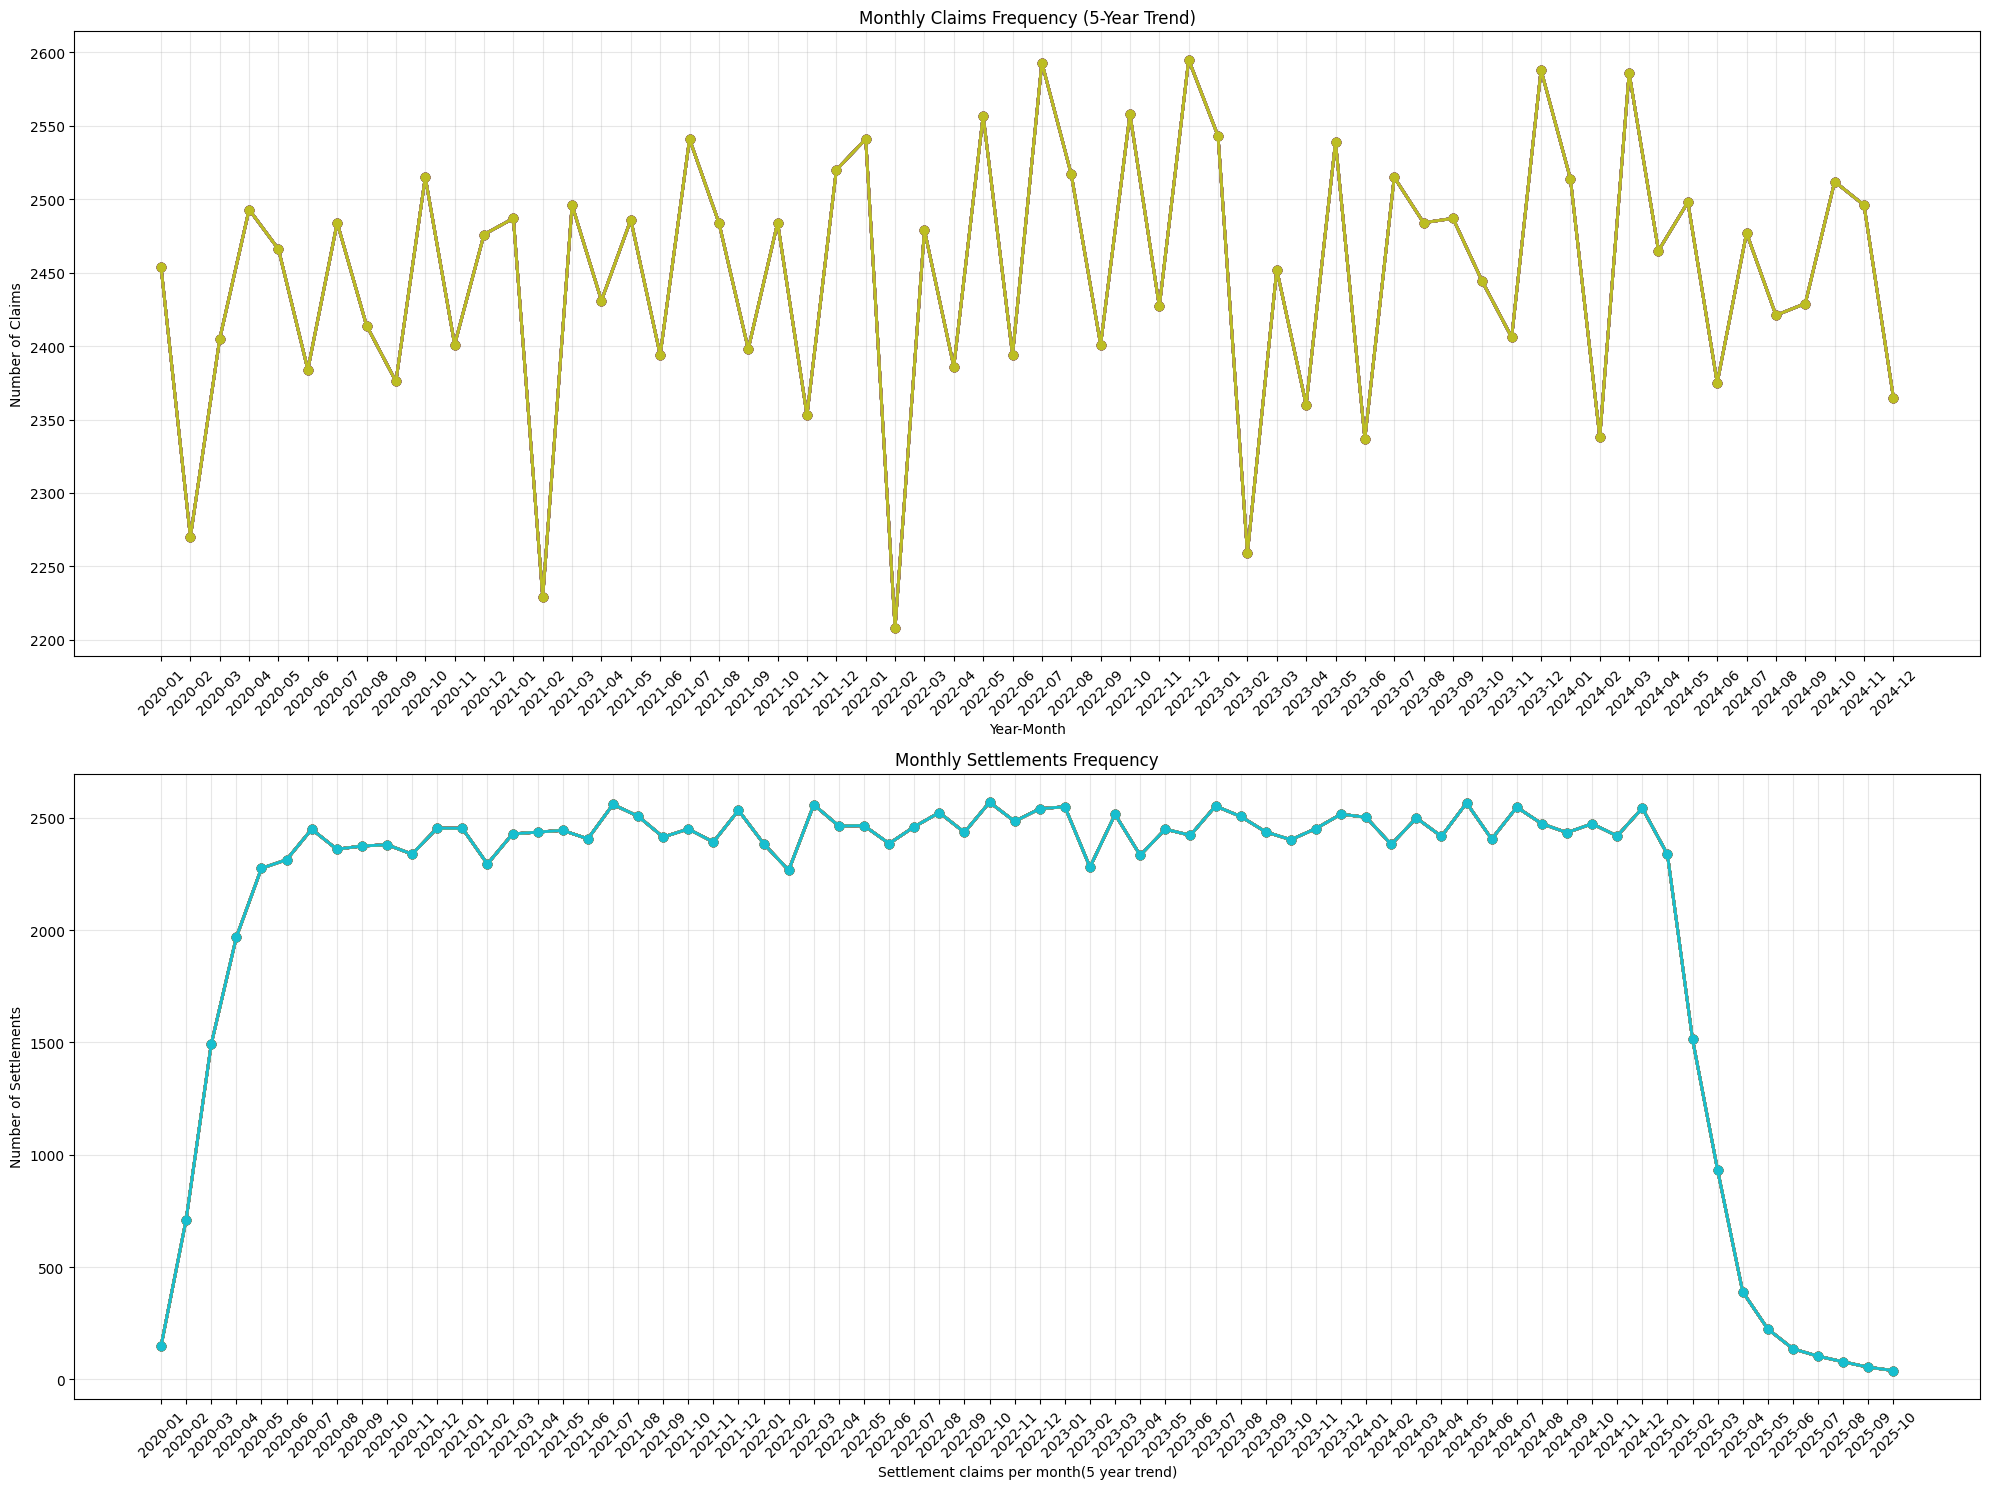

In [35]:
claims_data['Accident_YearMonth'] = claims_data['Accident_Date'].dt.strftime('%Y-%m')
plt.figure(figsize = (20, 15))

plt.subplot(2, 1, 1)
monthly_claims = claims_data.groupby('Accident_YearMonth').count()
plt.plot(monthly_claims.index.astype(str), monthly_claims.values, marker='o', linewidth=2)
plt.title('Monthly Claims Frequency (5-Year Trend)')
plt.xlabel('Year-Month')
plt.ylabel('Number of Claims')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(2, 1, 2)
claims_data['Settlement_YearMonth'] = claims_data['Settlement_Date'].dt.strftime('%Y-%m')
settlement_permonth = claims_data.groupby('Settlement_YearMonth').count()
plt.plot(settlement_permonth.index.astype(str), settlement_permonth.values, marker='o', linewidth=2)
plt.title('Monthly Settlements Frequency')
plt.xlabel('Settlement claims per month(5 year trend)')
plt.ylabel('Number of Settlements')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Bi-Variate Expoloratory Data Analysis

1. Claim Type vs Ultimate claim
2. Weather Condition vs Ultimate claim
3. vehicletype vs ulitmate claim 


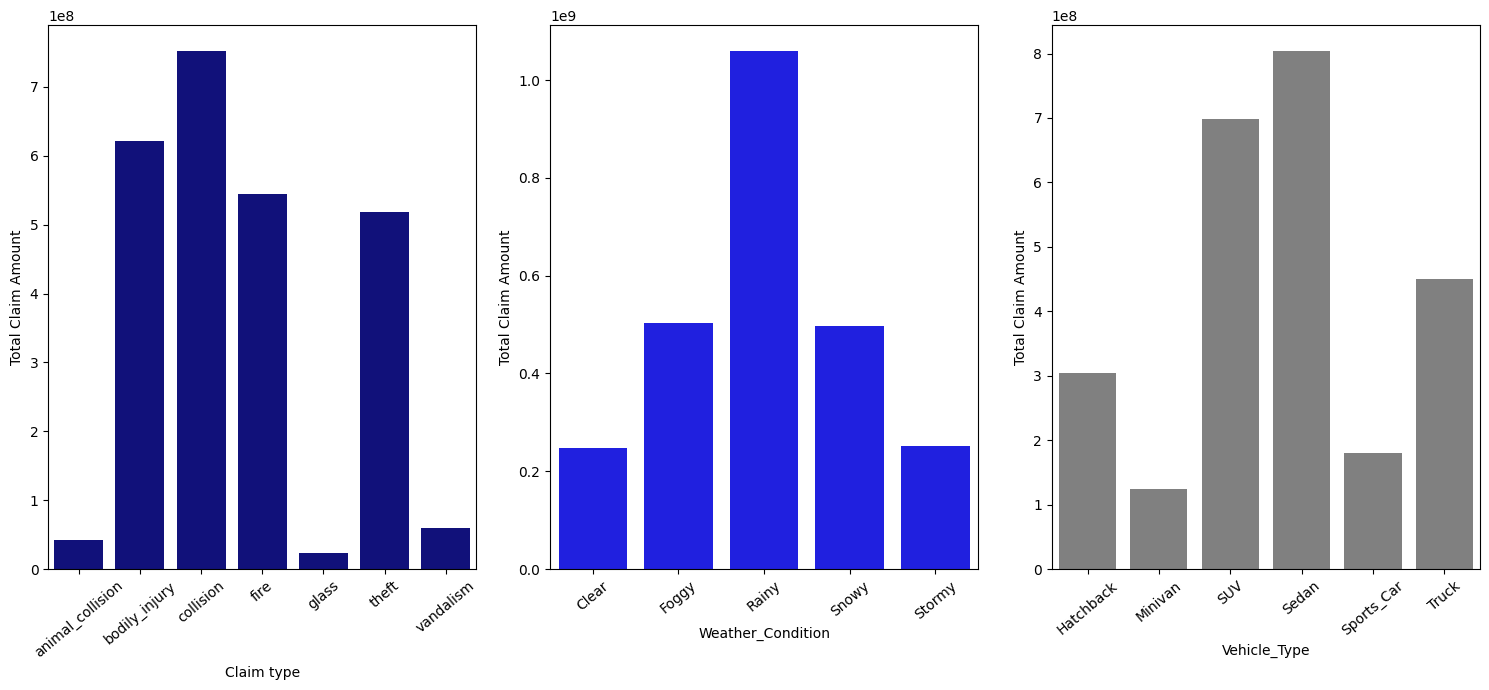

In [36]:

plt.figure(figsize = (15, 7))

claim_type_per_amount = claims_data.groupby("Claim_Type").agg({
    'Estimated_Claim_Amount': 'sum',
    'Ultimate_Claim_Amount': 'sum',
}).reset_index()

weather_claim_impact = claims_data.groupby("Weather_Condition").agg({
   'Estimated_Claim_Amount': 'sum',
   'Ultimate_Claim_Amount': 'sum',  
}).reset_index()

vechicle_type_per_amount = claims_data.groupby("Vehicle_Type").agg({
    'Estimated_Claim_Amount': 'sum',
    'Ultimate_Claim_Amount': 'sum',  
})


plt.subplot(1, 3, 1)
sns.barplot(x = "Claim_Type", y = "Ultimate_Claim_Amount", data = claim_type_per_amount, color="darkblue")
plt.xlabel("Claim type")
plt.ylabel("Total Claim Amount")
plt.xticks(rotation=40)


plt.subplot(1, 3, 2)
sns.barplot(x = "Weather_Condition", y = "Ultimate_Claim_Amount", data = weather_claim_impact, color="blue")
plt.xlabel("Weather_Condition")
plt.ylabel("Total Claim Amount")
plt.xticks(rotation=40)



plt.subplot(1, 3, 3)
sns.barplot(x = "Vehicle_Type", y = "Ultimate_Claim_Amount", data = vechicle_type_per_amount, color = "grey")
plt.xlabel("Vehicle_Type")
plt.ylabel("Total Claim Amount")
plt.xticks(rotation=40)

plt.tight_layout()
plt.show()

## Checking for outliers using Boxplot

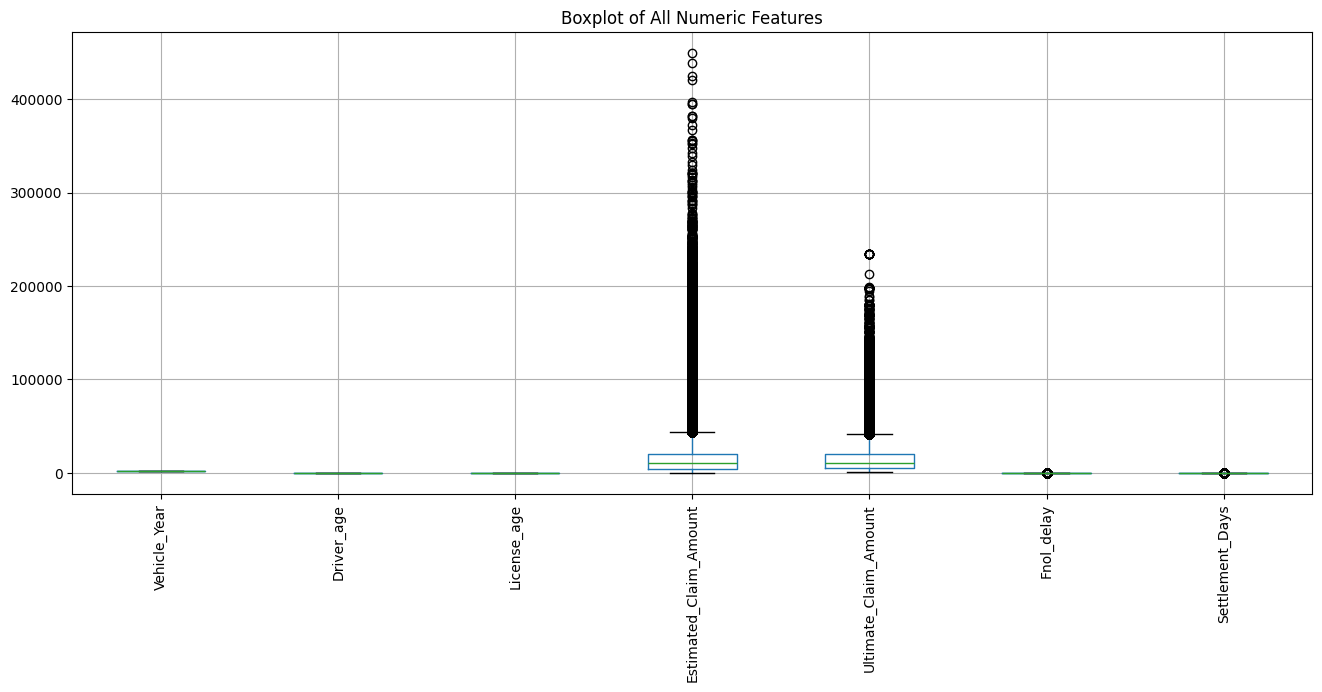

In [37]:
numeric_features = ['Vehicle_Year', 'Driver_age', 'License_age', 'Estimated_Claim_Amount', 'Ultimate_Claim_Amount', 'Fnol_delay', 'Settlement_Days']

plt.figure(figsize=(16, 6))
claims_data[numeric_features].boxplot(rot=90)
plt.title("Boxplot of All Numeric Features")
plt.show()


## Getting outlier values

In [38]:
def get_iqr_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    return mask

iqr_outliers = pd.DataFrame()

for col in numeric_features:
    iqr_outliers[col] = get_iqr_outlier(claims_data, col)

print(iqr_outliers.sum())

Vehicle_Year                  0
Driver_age                    0
License_age                   0
Estimated_Claim_Amount    13022
Ultimate_Claim_Amount     14735
Fnol_delay                14633
Settlement_Days            9900
dtype: int64


## Fixing outliers

In [39]:
import pandas as pd


def winsorize(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[column] = df[column].clip(lower_bound, upper_bound)
    return df


In [40]:
outlier_columns = ["Estimated_Claim_Amount", "Ultimate_Claim_Amount", "Fnol_delay", "Settlement_Days"]
# Apply winsorization to all outlier columns
for col in outlier_columns:
    claims_data = winsorize(claims_data, col)

print("Outliers corrected successfully!")


Outliers corrected successfully!


### Validating if the outliers still existed

In [41]:
for col in numeric_features:
    iqr_outliers[col] = get_iqr_outlier(claims_data, col)

print(iqr_outliers.sum())

Vehicle_Year              0
Driver_age                0
License_age               0
Estimated_Claim_Amount    0
Ultimate_Claim_Amount     0
Fnol_delay                0
Settlement_Days           0
dtype: int64


### Using boxplot

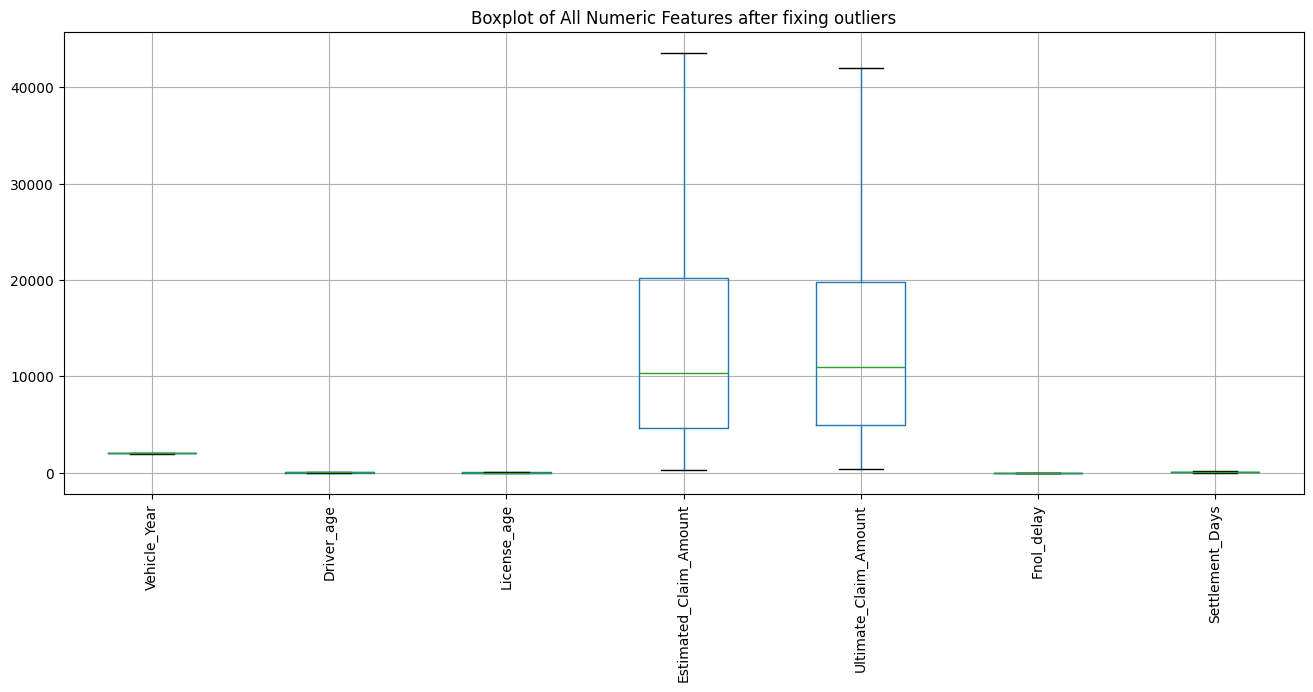

In [42]:
plt.figure(figsize=(16, 6))
claims_data[numeric_features].boxplot(rot=90)
plt.title("Boxplot of All Numeric Features after fixing outliers")
plt.show()

In [43]:
claims_data.to_csv("FNOL_Data/claims_policy_merged_cleaned.csv", index=False)

#### Addressing the skewness in target variable Ultimate_Claim_Amount using log transformation

In [44]:
#### Addressing the skewness in target variable Ultimate_Claim_Amount and Estimated_Claim_Amount using log transformation
claims_data['Ultimate_Claim_Amount'] = np.log1p(claims_data['Ultimate_Claim_Amount'])

## Feature Selection

In [45]:
claims_data.head()

,Claim_ID,Policy_ID,Customer_ID,Accident_Date,FNOL_Date,Claim_Type,Estimated_Claim_Amount,Ultimate_Claim_Amount,Settlement_Date,Traffic_Condition,...,Date_of_Birth,Full_License_Issue_Date,Vehicle_Type,Vehicle_Year,Driver_age,License_age,Fnol_delay,Settlement_Days,Accident_YearMonth,Settlement_YearMonth
0,CLM_000001,POL_000001,CUST_77820,2020-03-02,2020-03-06,fire,8761.43,9.351058,2020-06-26,Low,...,1983-04-20,2003-08-23,Sedan,2008,36,16,4,112.0,2020-03,2020-06
1,CLM_000002,POL_000002,CUST_88498,2023-01-09,2023-01-10,fire,12896.76,9.646723,2023-03-21,Low,...,1986-03-10,2007-07-26,Hatchback,2012,36,15,1,70.0,2023-01,2023-03
2,CLM_000003,POL_000003,CUST_60735,2022-12-25,2022-12-26,collision,12698.97,9.510519,2023-02-01,Low,...,1971-03-02,1989-07-05,Hatchback,2021,51,33,1,37.0,2022-12,2023-02
3,CLM_000004,POL_000003,CUST_60735,2021-11-24,2021-11-29,vandalism,2738.35,7.906886,2021-12-13,Moderate,...,1971-03-02,1989-07-05,Hatchback,2021,50,32,5,14.0,2021-11,2021-12
4,CLM_000005,POL_000003,CUST_60735,2022-10-01,2022-10-08,collision,16262.58,9.302631,2022-12-06,Moderate,...,1971-03-02,1989-07-05,Hatchback,2021,51,33,6,59.0,2022-10,2022-12


In [46]:
claims_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146987 entries, 0 to 146986
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Claim_ID                 146987 non-null  object        
 1   Policy_ID                146987 non-null  object        
 2   Customer_ID              146987 non-null  object        
 3   Accident_Date            146987 non-null  datetime64[ns]
 4   FNOL_Date                146987 non-null  datetime64[ns]
 5   Claim_Type               146987 non-null  object        
 6   Estimated_Claim_Amount   146987 non-null  float64       
 7   Ultimate_Claim_Amount    146987 non-null  float64       
 8   Settlement_Date          146987 non-null  datetime64[ns]
 9   Traffic_Condition        146987 non-null  object        
 10  Weather_Condition        146987 non-null  object        
 11  Date_of_Birth            146987 non-null  datetime64[ns]
 12  Full_License_Iss

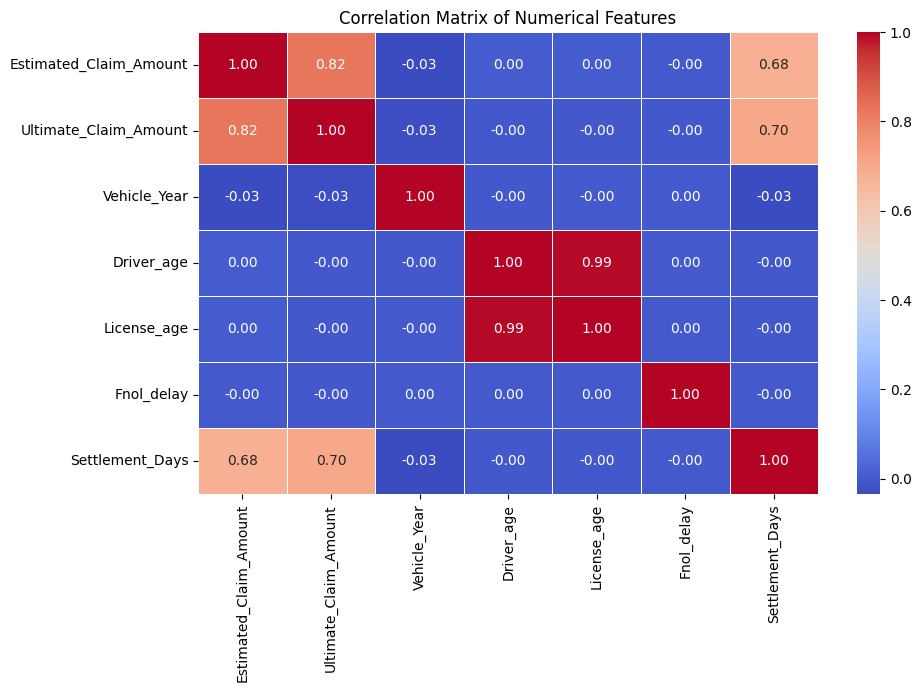

In [47]:
# Select only numerical columns
numeric_df = claims_data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [48]:
features = ['Claim_Type',
 'Estimated_Claim_Amount', 
 'Traffic_Condition', 
 'Weather_Condition', 
 'Vehicle_Type', 
 'Vehicle_Year', 
 'Driver_age',
 'License_age',
]

target = ['Ultimate_Claim_Amount']


In [49]:
claims_data = claims_data[features + target]

In [50]:
categorical_features = ['Traffic_Condition', 'Weather_Condition', 'Vehicle_Type', 'Claim_Type']
claims_data = pd.get_dummies(claims_data, columns=categorical_features, drop_first=False, dtype=int)

In [51]:
X = claims_data.drop("Ultimate_Claim_Amount", axis=1)
y = claims_data["Ultimate_Claim_Amount"]

In [52]:
X.head()

,Estimated_Claim_Amount,Vehicle_Year,Driver_age,License_age,Traffic_Condition_High,Traffic_Condition_Low,Traffic_Condition_Moderate,Traffic_Condition_Severe,Weather_Condition_Clear,Weather_Condition_Foggy,...,Vehicle_Type_Sedan,Vehicle_Type_Sports_Car,Vehicle_Type_Truck,Claim_Type_animal_collision,Claim_Type_bodily_injury,Claim_Type_collision,Claim_Type_fire,Claim_Type_glass,Claim_Type_theft,Claim_Type_vandalism
0,8761.43,2008,36,16,0,1,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
1,12896.76,2012,36,15,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,12698.97,2021,51,33,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,2738.35,2021,50,32,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,16262.58,2021,51,33,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [53]:
y.head()

0    9.351058
1    9.646723
2    9.510519
3    7.906886
4    9.302631
Name: Ultimate_Claim_Amount, dtype: float64

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, 
y, 
test_size=0.2,
random_state = 42
)

## Model Development

• Linear Regression

• Random Forest

• Gradient Boosting 

### Random Forest and the Behind the Scene


**Introduction to Random Forest**
Random Forest is an ensemble machine learning algorithm that combines the predictions of multiple decision trees to improve accuracy and reduce overfitting. It can be used for both classification and regression tasks. Unlike a single decision tree, which is prone to high variance and can easily overfit the training data, Random Forest mitigates these issues by averaging the results of many trees, making the model more robust and generalizable. The term “forest” refers to the collection of multiple trees that work together to produce a final prediction.

---

**Building Individual Trees**
At the core of Random Forest are individual decision trees. Each tree is trained on a random subset of the data, a process known as **bootstrap sampling** or bagging. This means that for each tree, a sample of the dataset is drawn **with replacement**, so some samples may appear multiple times while others may be excluded. This randomness ensures that each tree is slightly different, increasing the diversity of the ensemble and improving overall model performance. During tree construction, nodes are split based on feature values to maximize purity in the resulting child nodes, using metrics such as Gini impurity for classification or mean squared error for regression.

---

**Random Feature Selection**
Random Forest introduces additional randomness by limiting the number of features considered at each split, controlled by the `max_features` parameter. Instead of evaluating all available features, each node considers only a random subset of features. This reduces correlation between individual trees, ensuring that the ensemble benefits from a diverse set of decision rules. By doing so, even if some features dominate in the dataset, no single feature controls all trees, which improves generalization.

---

**Making Predictions**
Once all trees are trained, the Random Forest predicts outcomes by aggregating individual tree predictions. For **classification**, it uses a majority voting mechanism, where the class predicted by the most trees is chosen as the final output. For **regression**, the predictions from all trees are averaged. This aggregation reduces variance and smooths out the noise that might be present in individual tree predictions, making Random Forest highly reliable in practice.

---

**Handling Overfitting and Bias-Variance Tradeoff**
Random Forest balances the bias-variance tradeoff effectively. Individual trees are low-bias but high-variance learners—they can capture complex patterns but overfit easily. By averaging many trees, Random Forest reduces variance without significantly increasing bias. Parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf` further control tree complexity, while `n_estimators` ensures enough trees are included to stabilize predictions. This combination allows the model to generalize well to unseen data.

---

**Feature Importance and Interpretability**
Beyond prediction, Random Forest provides insight into feature importance. By analyzing how much each feature contributes to reducing impurity across all trees, the model can rank features by their predictive power. This makes Random Forest a powerful tool not only for prediction but also for understanding which variables drive outcomes. However, while the ensemble is robust, the individual decision rules are less interpretable than a single tree, making the overall model a “black box” in some respects.

---

**Computational Considerations**
Behind the scenes, Random Forest is computationally intensive, especially with many trees or deep trees. Each tree is independent, which allows parallelization to speed up training. Memory usage scales with the number of trees and dataset size. Hyperparameters such as `n_estimators`, `max_depth`, and `max_features` allow fine-tuning to achieve a balance between accuracy, training time, and memory efficiency.

---

**Conclusion**
In summary, Random Forest works by building a collection of diverse decision trees using random samples of data and features. Each tree contributes to the final prediction, reducing variance and improving robustness compared to a single tree. Its combination of randomness, ensemble averaging, and hyperparameter control makes it a powerful and widely used algorithm for both classification and regression tasks, providing high accuracy, stability, and feature insights.

![Screenshot 2025-12-15 165631.png](<attachment:Screenshot 2025-12-15 165631.png>)
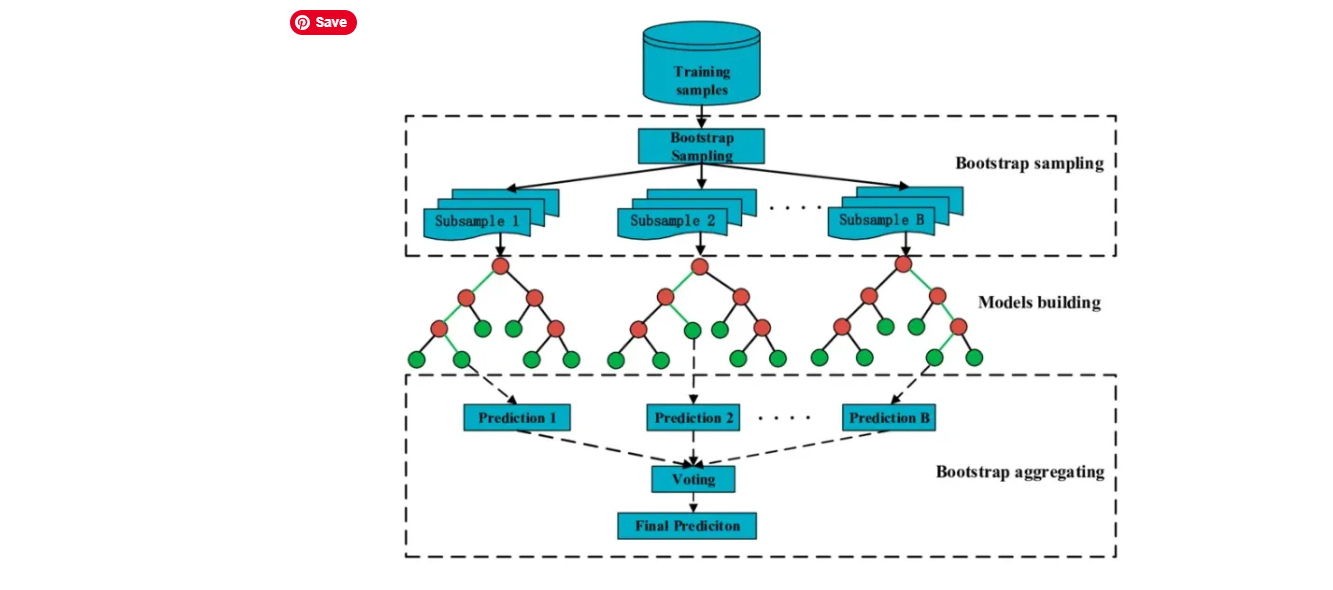

In [55]:
Random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
Random_forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
Rf_pred_log = Random_forest_model.predict(X_test)



In [57]:
rf_pred_actual = np.expm1(Rf_pred_log)

In [58]:
rf_pred_actual[:10]

array([37087.59893834, 19137.88090825, 11938.88413376, 12178.94645232,
        9443.88482997, 12311.35655015,  5577.74146124, 27433.74836669,
       34485.09860349, 19098.72537649])

In [59]:
y_test = np.expm1(y_test)
y_test[:10]

2136      41983.1675
26563     12050.8500
48955     14850.0000
113544    15939.2200
85113      9227.8400
38001     20180.8000
127421     6000.0000
103538    22116.4900
96573     41983.1675
131673    18253.4000
Name: Ultimate_Claim_Amount, dtype: float64

In [60]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluation_metrics(X_test, y_test, model):
    # Predict in log scale and transform back
    model_pred_log = model.predict(X_test)
    model_pred = np.expm1(model_pred_log)
    
    # Metrics
    mae = mean_absolute_error(y_test, model_pred)
    mse = mean_squared_error(y_test, model_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, model_pred)
    
    print("MAE =", mae)
    print("MSE =", mse)
    print("RMSE =", rmse)
    print("R2 Score =", r2)

evaluation_metrics(X_test, y_test, Random_forest_model)


MAE = 2529.8845037202195
MSE = 18111979.521569572
RMSE = 4255.817139113189
R2 Score = 0.8886877204359541


### Linear Regression Model

**Introduction to Linear Regression**
Linear Regression is a predictive modeling technique used to estimate the value of a target variable based on one or more input features. Unlike complex models, it assumes a straightforward relationship between the features and the target: as the input changes, the prediction changes proportionally. It is widely used because of its simplicity and interpretability, making it easy to understand how inputs affect outputs.

---

**Learning from Data**
Behind the scenes, Linear Regression “learns” patterns from the training data by examining how the target variable responds to changes in each feature. It analyzes the data to determine the contribution of each feature to the outcome. Essentially, it looks for the best way to combine all features so that the predictions for the training examples are as close as possible to the actual values.

---

**Making Predictions**
When predicting new data, Linear Regression takes the values of the input features and combines them according to what it has learned during training. Each feature has a “weight” that reflects its importance in determining the target. The model adds up the contributions of all features to produce a single prediction. Because it learned from the patterns in the training data, it can estimate outcomes for new, unseen data based on similar relationships.

---

**Handling Variation and Noise**
In real-world data, outcomes are rarely perfectly predictable. Linear Regression accounts for this by not trying to fit every tiny fluctuation. Instead, it finds a trend that best represents the general relationship between features and the target. This allows the model to make stable predictions even when individual data points contain noise or small inconsistencies.

---

**Feature Contribution and Interpretability**
One of the key aspects of Linear Regression is that it clearly identifies how each feature influences the prediction. Features with larger contributions have a stronger effect on the predicted outcome, while features with smaller contributions have less influence. This makes it easy to interpret the results and understand which factors are driving predictions, which is useful for decision-making and reporting.

---

**Efficiency and Simplicity**
Linear Regression is computationally simple and fast. It doesn’t require complex iterative processes like ensemble methods or deep learning models. This efficiency allows it to quickly generate predictions, even for large datasets, making it ideal for scenarios where speed and interpretability are more important than capturing highly complex patterns.
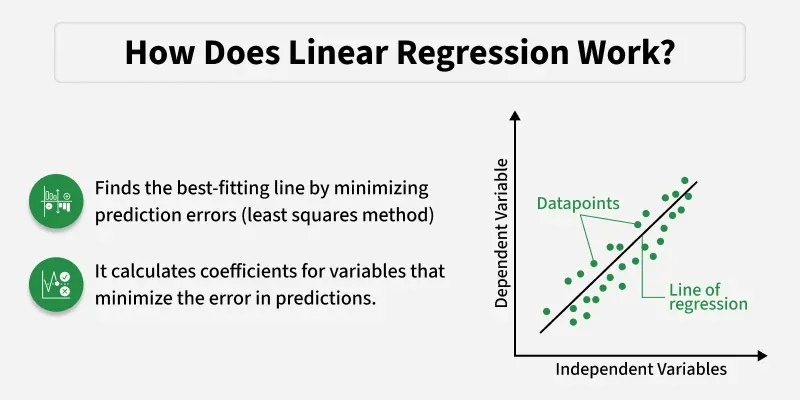



In [61]:
from sklearn.linear_model import LinearRegression

In [62]:
Linear_Regression_Model =  LinearRegression()

In [63]:
Linear_Regression_Model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
evaluation_metrics(X_test = X_test, y_test = y_test, model = Linear_Regression_Model)

MAE = 3925.3560129397997
MSE = 37300753.792126164
RMSE = 6107.434305183001
R2 Score = 0.7707576949767344


### Gradient Boost Regression Model


### 1. **The Core Idea**

Gradient Boosting is like **building a team of helpers** to fix a problem:

* You start with a very simple prediction (like guessing the average).
* Each new helper (a small decision tree) focuses only on **what the previous helpers got wrong**.
* You keep adding helpers one by one, each improving the model a little.
* At the end, all helpers together make a very strong predictor.

---

### 2. **How It Works Step by Step**

**Step 1: Start simple**
The first model is very basic—it doesn’t know much. For example, it might just predict the average outcome for all cases.

**Step 2: Look at mistakes**
We check where the first model went wrong. These errors show **where we need improvement**.

**Step 3: Train a new small tree**
The next tree doesn’t try to predict the full outcome. It only tries to **fix the mistakes** of the first model.

**Step 4: Combine predictions**
We add this new tree to the previous model. Now the combined model is slightly better.

**Step 5: Repeat**
We repeat this process:

* Look at remaining mistakes
* Train another small tree to fix them
* Add it to the model

After many rounds, the combined model becomes very strong.

---

### 3. **Why It Works**

* Each tree is “weak” on its own, but together they correct each other’s mistakes.
* By adding small improvements gradually, the model **avoids overreacting** to any single mistake.
* The process focuses on **learning from errors**, which makes it very effective for complex patterns.

---

### 4. **Behind-the-Scene Tricks**

* Trees are usually shallow, so each one is simple and only captures small patterns.
* We control how much each tree contributes (like saying “slow down, don’t overfix”)—this prevents overfitting.
* Sometimes only part of the data or part of the features is used for each tree, to make the model more robust.

---

### 5. **Analogy**

Imagine you are **painting a mural**:

* First, you cover the wall with a base color.
* Then you notice spots that need touch-ups and add small layers of paint to fix them.
* Each new layer only fixes what’s missing or wrong from previous layers.
* Eventually, the wall looks perfect, even though each layer alone was simple.

In [65]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor


In [66]:
Gradient_Boost_model = GradientBoostingRegressor()

In [67]:
Gradient_Boost_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [68]:
evaluation_metrics(X_test = X_test, y_test = y_test, model = Gradient_Boost_model)


MAE = 2579.168027750913
MSE = 18254049.87627966
RMSE = 4272.475848530879
R2 Score = 0.8878145869928415


## Hyperparameter Tuning

**Number of Trees (`n_estimators`)**
The `n_estimators` parameter specifies the number of decision trees in the Random Forest ensemble. In your grid, it is set to `[100, 200, 300]`, meaning that the model will be evaluated with 100, 200, and 300 trees. A higher number of trees generally improves the stability and accuracy of the model because the ensemble averages the predictions of more trees, reducing variance. However, more trees also increase computation time and memory usage. By testing different values, one can identify the optimal balance between predictive performance and computational efficiency.

---

**Maximum Tree Depth (`max_depth`)**
The `max_depth` parameter controls the maximum depth of each decision tree. Depth determines how many successive splits a tree can make before stopping. In your grid, the values `[10, 20, None]` are considered. Shallow trees (e.g., depth 10) may underfit the data because they cannot capture complex patterns. Moderate depths (e.g., 20) balance capturing complexity and avoiding overfitting. Setting it to `None` allows trees to grow fully until all leaves are pure, which can capture maximum detail but carries a higher risk of overfitting. Adjusting `max_depth` is critical for controlling model complexity and generalization.

---

**Minimum Samples to Split (`min_samples_split`)**
The `min_samples_split` parameter defines the minimum number of samples required to split an internal node. With values `[2, 5, 10]`, smaller numbers allow nodes to split with very few samples, creating highly detailed trees that may overfit the training data. Larger numbers prevent splits unless enough data is present, resulting in simpler trees that generalize better. This parameter is important for controlling how aggressively a tree grows and influences both the bias and variance of the model.

---

**Minimum Samples at Leaf (`min_samples_leaf`)**
The `min_samples_leaf` parameter specifies the minimum number of samples that must be present in a leaf node. Your grid includes `[1, 2, 4]`. Leaves with very few samples (e.g., 1) can capture noise and cause overfitting, while higher values create leaves with more representative data, leading to smoother and more generalizable decision boundaries. Adjusting this parameter helps reduce model variance without significantly increasing bias, improving robustness, especially for datasets with many features or imbalanced classes.

---

**Maximum Features per Split (`max_features`)**
The `max_features` parameter determines the number of features to consider when finding the best split for a node. In your grid, it is set to `['sqrt', 'log2']`. The `'sqrt'` option uses the square root of the total number of features, while `'log2'` uses the base-2 logarithm. Limiting the number of features introduces randomness, reduces correlation between trees, and enhances ensemble performance. Choosing different strategies allows the model to explore a balance between individual tree strength and ensemble diversity, which is essential for controlling overfitting and improving prediction accuracy.

---

**Usage in Hyperparameter Tuning**
Overall, this `param_grid` defines the search space for hyperparameter tuning, typically used with `GridSearchCV`. Each combination of the parameters will be evaluated using cross-validation to find the optimal set of hyperparameters. For your grid, there are 162 possible combinations. By systematically testing these combinations, the model can identify the configuration that offers the best predictive performance while maintaining generalization, balancing complexity, randomness, and computational efficiency.

---

In [69]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


In [70]:

from sklearn.model_selection import RandomizedSearchCV
Random_Forest_hyper = RandomizedSearchCV(
    estimator = RandomForestRegressor(random_state=42),
    param_distributions = param_grid,
    n_iter = 10,
    cv = 5,
    verbose = 1,
    n_jobs = -1
)

In [71]:
Random_Forest_hyper.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [72]:
Best_rf_model = Random_Forest_hyper.best_estimator_

In [73]:
evaluation_metrics(X_test = X_test, y_test = y_test, model = Best_rf_model)


MAE = 2645.1358937040773
MSE = 18252232.32962735
RMSE = 4272.263139090024
R2 Score = 0.8878257572385257


### Model Tracking Using MLFlow

In [74]:
import mlflow

In [75]:
mlflow.set_tracking_uri("file:///C:/Users/HP/Desktop/FNOL Project/mlruns")


In [76]:
mlflow.set_experiment("fnol_ultimate_claim_experiment")

2025/12/13 12:50:50 INFO mlflow.tracking.fluent: Experiment with name 'fnol_ultimate_claim_experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/Users/HP/Desktop/FNOL Project/mlruns/637774705093931540', creation_time=1765626650530, experiment_id='637774705093931540', last_update_time=1765626650530, lifecycle_stage='active', name='fnol_ultimate_claim_experiment', tags={}>

In [77]:
mlflow.get_tracking_uri()

'file:///C:/Users/HP/Desktop/FNOL Project/mlruns'

In [78]:
models = {
"rf_model": Random_forest_model,
"linearReg_model": Linear_Regression_Model,
"GradientBoost_model": Gradient_Boost_model,
"Tuned_rf_model":Best_rf_model
}

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for model_name, model in models.items():
    with mlflow.start_run(run_name = model_name):

        # Log parameters (model hyperparameters)
        if hasattr(model, "get_params"):
            mlflow.log_params(model.get_params())

        model_pred_log = model.predict(X_test)
        preds = np.expm1(model_pred_log)
    

        mae = mean_absolute_error(y_test, preds)
        mse = mean_squared_error(y_test, preds)
        r2 = r2_score(y_test, preds)


        mlflow.log_metrics({
            "MAE":mae,
            "MSE":mse,
            "R2":r2
        })

        mlflow.sklearn.log_model(model, model_name)

print("All models logged successfully")

2025/12/13 12:50:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/13 12:51:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/12/13 12:51:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/13 12:51:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/12/13 12:51:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/13 12:52:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/12/13 12:52:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use 

All models logges successfully


In [80]:
mlflow.get_tracking_uri()

'file:///C:/Users/HP/Desktop/FNOL Project/mlruns'

### SHAP + LIME

In [81]:
best_model = Random_forest_model

  0%|          | 0/5 [00:00<?, ?it/s]

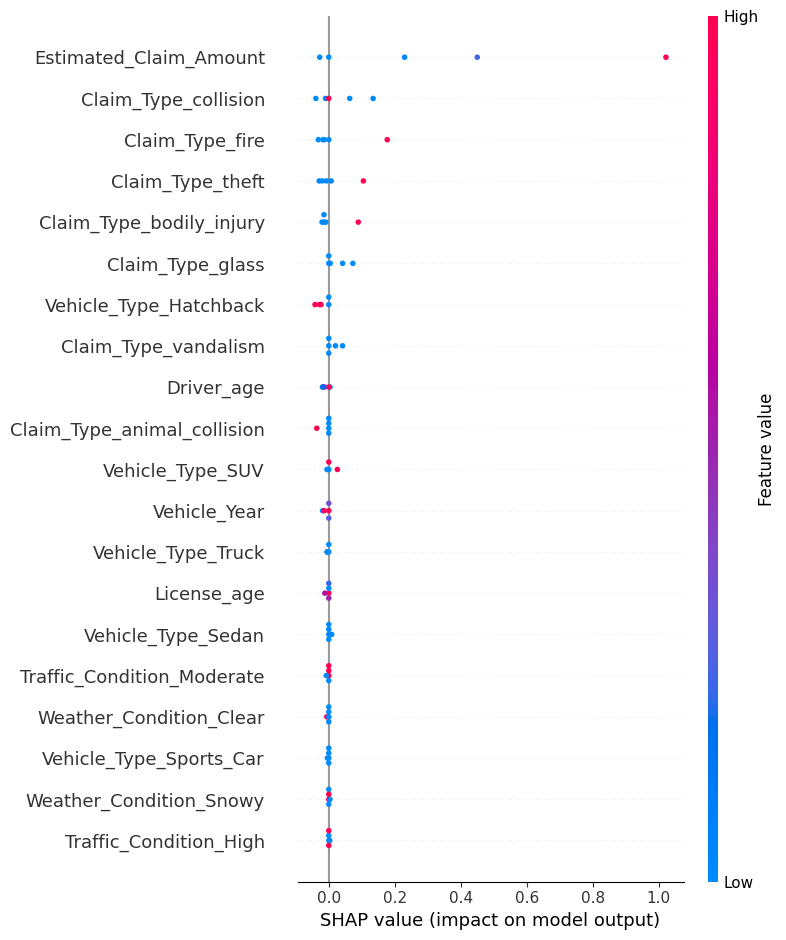

In [82]:
import shap
import pandas as pd

# Create a wrapper function that handles the pipeline
def pipeline_predict(X):
    # If X is a numpy array, convert it back to DataFrame with original column names
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train.columns)
    return best_model.predict(X)

# Use smaller background data
X_background = shap.sample(X_train, 100)
X_test_sample_small = X_test.iloc[:5]

# Use KernelExplainer with the wrapper
explainer = shap.KernelExplainer(pipeline_predict, X_background)
shap_values = explainer.shap_values(X_test_sample_small)

# Plot results
shap.summary_plot(shap_values, X_test_sample_small)

### Feature Importances

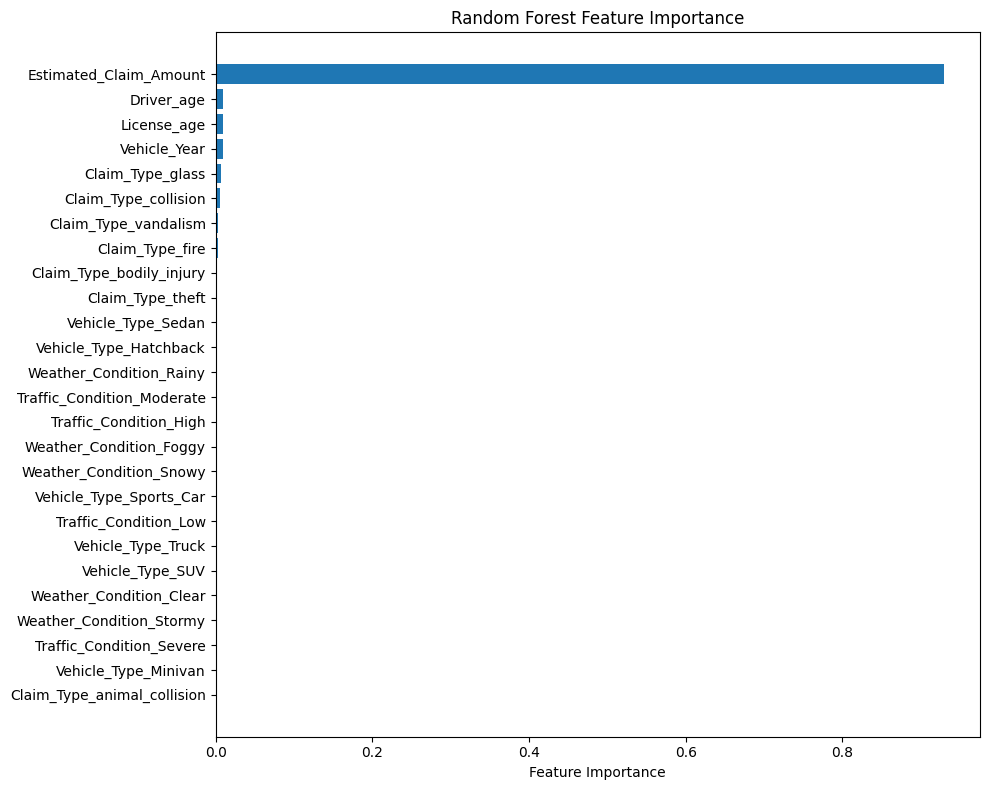

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# Replace these with your objects
model = Random_forest_model
feature_names = X_train.columns

# Extract importances
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), feature_names[indices])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


## Saving the best model

In [84]:
# Save it locally for deployment
os.makedirs("models", exist_ok=True)
joblib.dump(Random_forest_model, "models/best_model.pkl")

print("Model saved locally as models/best_model.pkl")


Model saved locally as models/best_model.pkl


In [86]:
feature_columns = X_train.columns.tolist()

with open("models/feature_columns.pkl", "wb") as f:
    joblib.dump(feature_columns, f)